In [1]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('./Dataset/LengthOfStay.csv')
df.sample(10)

,eid,vdate,rcount,gender,dialysisrenalendstage,asthma,irondef,pneum,substancedependence,psychologicaldisordermajor,...,glucose,bloodureanitro,creatinine,bmi,pulse,respiration,secondarydiagnosisnonicd9,discharged,facid,lengthofstay
28091,28092,11/28/2012,0,M,0,0,1,0,0,1,...,168.749610,22.0,0.854358,30.649807,71,6.4,1,12/3/2012,E,5
13140,13141,8/28/2012,0,F,0,0,0,0,0,0,...,120.120180,8.0,1.123926,28.523574,68,7.2,1,8/29/2012,A,1
86330,86331,5/10/2012,2,F,0,1,0,1,0,1,...,153.655519,5.0,1.359483,33.027651,87,6.5,0,5/17/2012,E,7
45335,45336,12/8/2012,4,M,0,0,0,0,0,0,...,154.180855,12.0,1.162826,28.143453,78,6.5,3,12/14/2012,B,6
54355,54356,8/16/2012,0,F,0,1,0,0,0,1,...,153.561909,12.0,0.787461,32.564449,70,6.5,0,8/20/2012,D,4
90146,90147,12/22/2012,1,F,0,0,0,0,0,1,...,188.154647,12.0,1.580357,32.407097,65,6.5,0,12/28/2012,E,6
11676,11677,10/6/2012,5+,M,0,0,0,0,0,0,...,117.087261,12.0,1.064964,24.694350,83,6.5,1,10/13/2012,B,7
85147,85148,12/2/2012,0,M,1,0,0,0,1,1,...,127.778759,30.0,0.834913,29.942246,80,5.3,1,12/9/2012,E,7
9261,9262,8/23/2012,0,F,0,0,0,0,0,0,...,160.606922,12.0,1.298914,26.778936,70,6.5,1,8/25/2012,B,2
40812,40813,6/11/2012,2,M,0,0,0,0,0,1,...,126.030320,19.0,1.277140,32.227626,70,6.8,4,6/17/2012,E,6


In [3]:
df.shape

(100000, 28)

In [4]:
from sklearn.model_selection import train_test_split
df_train,df_test=train_test_split(df,test_size=0.2,random_state=42)

In [5]:
df_train.shape

(80000, 28)

In [6]:
df_train.duplicated().sum()

np.int64(0)

In [7]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 80000 entries, 75220 to 15795
Data columns (total 28 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   eid                         80000 non-null  int64  
 1   vdate                       80000 non-null  object 
 2   rcount                      80000 non-null  object 
 3   gender                      80000 non-null  object 
 4   dialysisrenalendstage       80000 non-null  int64  
 5   asthma                      80000 non-null  int64  
 6   irondef                     80000 non-null  int64  
 7   pneum                       80000 non-null  int64  
 8   substancedependence         80000 non-null  int64  
 9   psychologicaldisordermajor  80000 non-null  int64  
 10  depress                     80000 non-null  int64  
 11  psychother                  80000 non-null  int64  
 12  fibrosisandother            80000 non-null  int64  
 13  malnutrition                8000

In [8]:
df_train.isnull().sum()

eid                           0
vdate                         0
rcount                        0
gender                        0
dialysisrenalendstage         0
asthma                        0
irondef                       0
pneum                         0
substancedependence           0
psychologicaldisordermajor    0
depress                       0
psychother                    0
fibrosisandother              0
malnutrition                  0
hemo                          0
hematocrit                    0
neutrophils                   0
sodium                        0
glucose                       0
bloodureanitro                0
creatinine                    0
bmi                           0
pulse                         0
respiration                   0
secondarydiagnosisnonicd9     0
discharged                    0
facid                         0
lengthofstay                  0
dtype: int64

In [9]:
df_train.describe()

,eid,dialysisrenalendstage,asthma,irondef,pneum,substancedependence,psychologicaldisordermajor,depress,psychother,fibrosisandother,...,neutrophils,sodium,glucose,bloodureanitro,creatinine,bmi,pulse,respiration,secondarydiagnosisnonicd9,lengthofstay
count,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,...,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000
mean,50022.926437,0.036312,0.034975,0.094750,0.039350,0.062350,0.239325,0.052025,0.049212,0.004625,...,10.176926,137.885929,141.967963,14.106032,1.099373,29.806527,73.456275,6.491869,2.118325,4.001762
std,28869.648875,0.187068,0.183718,0.292871,0.194427,0.241792,0.426674,0.222079,0.216313,0.067850,...,5.145802,3.000821,30.039815,13.121823,0.200289,2.004944,11.661816,0.568923,2.047010,2.364747
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.100000,125.259814,-1.005927,1.000000,0.219770,21.992683,21.000000,0.200000,0.000000,1.000000
25%,25029.750000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,7.700000,135.854702,121.657115,11.000000,0.964624,28.452336,66.000000,6.500000,1.000000,2.000000
50%,50047.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,9.400000,137.889114,142.086522,12.000000,1.098796,29.814477,73.000000,6.500000,1.000000,4.000000
75%,75038.250000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,11.500000,139.906375,162.216634,14.000000,1.234741,31.164777,81.000000,6.500000,3.000000,6.000000
max,99999.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,245.900000,151.315937,271.444277,682.500000,2.035202,38.935293,126.000000,10.000000,10.000000,17.000000


In [10]:
df_train['lengthofstay'].value_counts()

lengthofstay
1     14416
3     12843
4     11795
2     10273
5      9674
6      8348
7      5765
8      3737
9      1753
10      800
11      371
12      111
13       61
14       29
15       15
16        6
17        3
Name: count, dtype: int64

<Axes: xlabel='lengthofstay', ylabel='Count'>

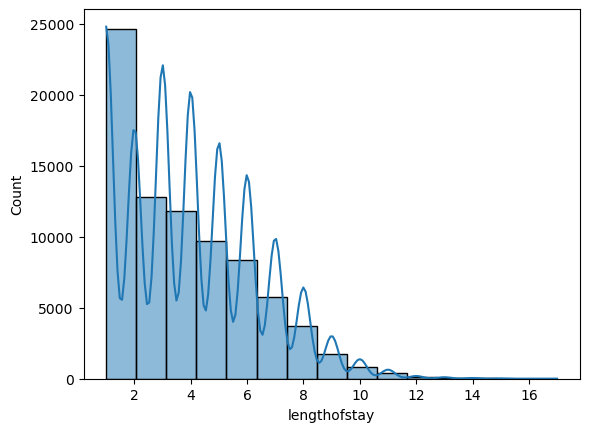

In [11]:
sb.histplot(df_train['lengthofstay'],bins=15,kde='True')

In [12]:
print(f"The skewness of target column is {df_train['lengthofstay'].skew()} and kurtosis is {df_train['lengthofstay'].kurtosis()}")

The skewness of target column is 0.6343562697523857 and kurtosis is 8.752670622769188e-05


In [14]:
df_train['vdate']=pd.to_datetime(df_train['vdate'],format="%m/%d/%Y")
df_train['vdate'][:5]

75220   2012-12-26
48955   2012-11-21
44966   2012-05-11
13568   2012-08-15
92727   2012-09-27
Name: vdate, dtype: datetime64[ns]

In [16]:
df_train['discharged']=pd.to_datetime(df_train['discharged'],format="%m/%d/%Y")
df_train['discharged'][:5]

75220   2012-12-31
48955   2012-11-28
44966   2012-05-17
13568   2012-08-20
92727   2012-10-03
Name: discharged, dtype: datetime64[ns]

In [17]:
df_train['rcount'].value_counts()

rcount
0     44006
1     12063
2      7978
3      6414
4      5566
5+     3973
Name: count, dtype: int64

In [ ]:
df_train['rcount']=df_train['rcount'].replace("5+","5")
df_train['rcount']=df_train['rcount'].astype(int)

In [23]:
df_train['rcount'].value_counts()

rcount
0    44006
1    12063
2     7978
3     6414
4     5566
5     3973
Name: count, dtype: int64

In [18]:
df_train['gender'].value_counts()

gender
F    46042
M    33958
Name: count, dtype: int64

In [19]:
df_train['facid'].value_counts()

facid
E    24556
B    24095
A    24008
C     3767
D     3574
Name: count, dtype: int64

<Axes: xlabel='pulse', ylabel='Count'>

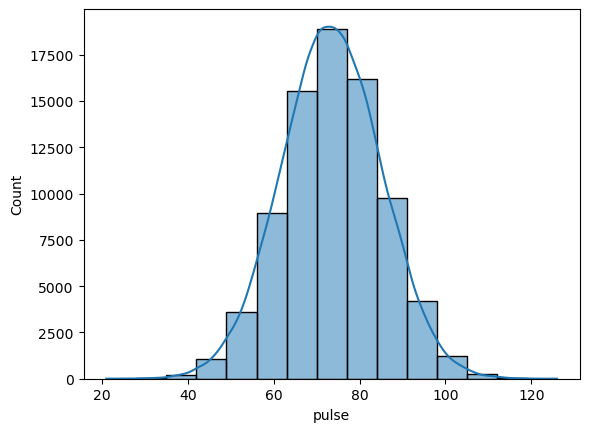

In [24]:
sb.histplot(df_train['pulse'],bins=15,kde='True')

In [25]:
print(f"The skewness of target column is {df_train['pulse'].skew()} and kurtosis is {df_train['pulse'].kurtosis()}")

The skewness of target column is 0.0015858735744729176 and kurtosis is 0.02207150597187013


In [26]:
df_train['secondarydiagnosisnonicd9'].value_counts()

secondarydiagnosisnonicd9
1     40065
0      8093
2      7879
3      7163
4      7154
5      3205
6      2479
7      1531
10      829
9       816
8       786
Name: count, dtype: int64

<Axes: xlabel='hematocrit', ylabel='Density'>

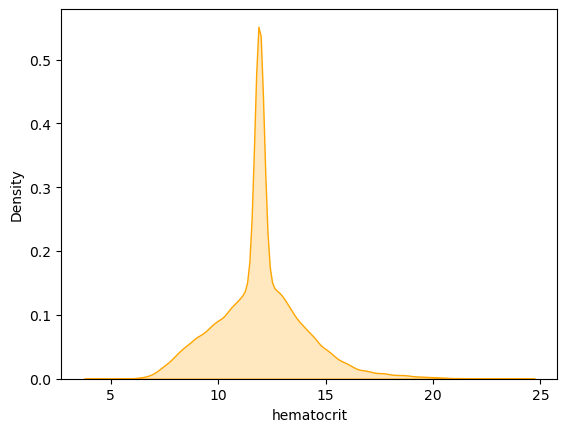

In [27]:
sb.kdeplot(data=df_train,x='hematocrit',fill=True,color='orange')

In [28]:
print(f"The skewness of target column is {df_train['hematocrit'].skew()} and kurtosis is {df_train['hematocrit'].kurtosis()}")

The skewness of target column is 0.5669205756256738 and kurtosis is 1.837769415761056


<Axes: xlabel='neutrophils', ylabel='Density'>

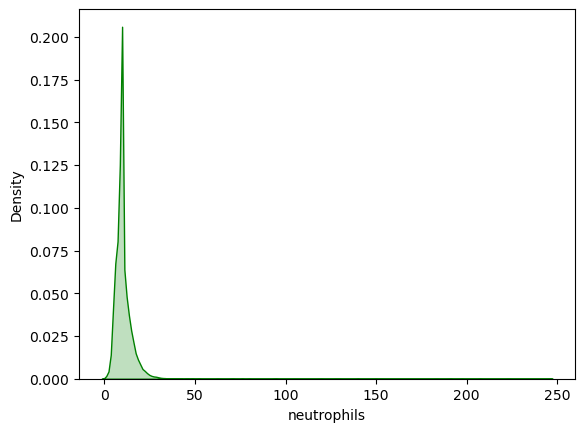

In [29]:
sb.kdeplot(data=df_train,x='neutrophils',fill=True,color='green')

In [30]:
print(f"The skewness of target column is {df_train['neutrophils'].skew()} and kurtosis is {df_train['neutrophils'].kurtosis()}")

The skewness of target column is 11.776888353309277 and kurtosis is 376.82479623780273


<Axes: xlabel='sodium', ylabel='Density'>

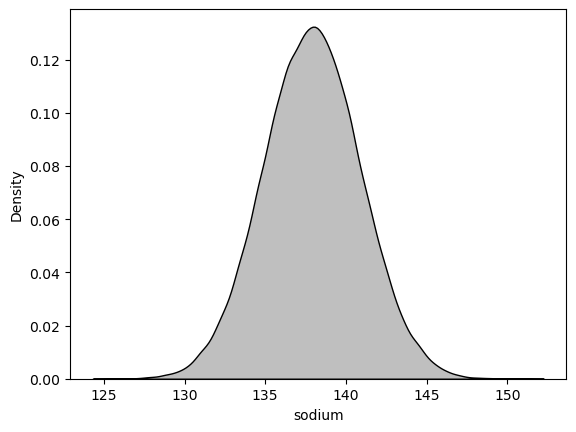

In [31]:
sb.kdeplot(data=df_train,x='sodium',fill=True,color='black')

In [32]:
print(f"The skewness of target column is {df_train['sodium'].skew()} and kurtosis is {df_train['sodium'].kurtosis()}")

The skewness of target column is 0.006109558794971963 and kurtosis is 0.007931981872051352


<Axes: xlabel='glucose', ylabel='Density'>

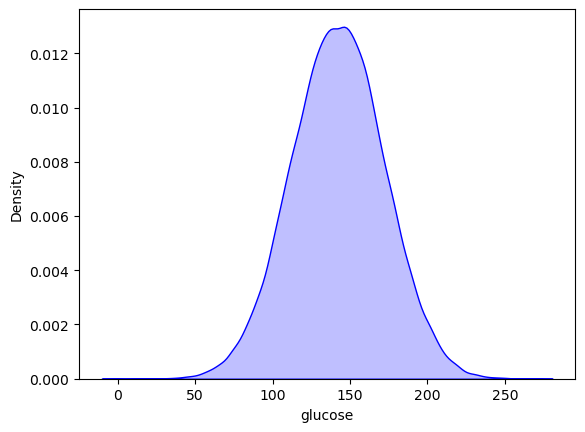

In [33]:
sb.kdeplot(data=df_train,x='glucose',fill=True,color='blue')

In [34]:
print(f"The skewness of target column is {df_train['glucose'].skew()} and kurtosis is {df_train['glucose'].kurtosis()}")

The skewness of target column is -0.013231620763942412 and kurtosis is 0.01117713041580437
